In [1]:
import numpy as np
import matplotlib.pyplot as plt
import helper
import odmrsimulator
import importlib
importlib.reload(odmrsimulator)

<module 'odmrsimulator' from 'c:\\working_dir\\nv_odmr\\quantum_sim-round1\\odmrsimulator.py'>

In [6]:
# Push these notebook settings into the odmrsimulator module so the
# dynamic D/T1/T2 functions pick up the values at call time (useful for MLE).

odmrsimulator.D0 = 2877
odmrsimulator.T0 = 300.
odmrsimulator.alpha = -0.72
# odmrsimulator.T1_0 = T1_0
# odmrsimulator.beta = beta
# odmrsimulator.T2_0 = T2_0
# odmrsimulator.gamma = gamma
# odmrsimulator.D_MHz = D_MHz
# odmrsimulator.D_rad_s = D_rad_s
# odmrsimulator.gamma_nv = gamma_nv
odmrsimulator.B = 0.
# If you want to enable strain, set E_rad_s in the module; otherwise keep None
odmrsimulator.E_rad_s = 3.14* 4 * 10e6
# odmrsimulator.strain_angle = strain_angle


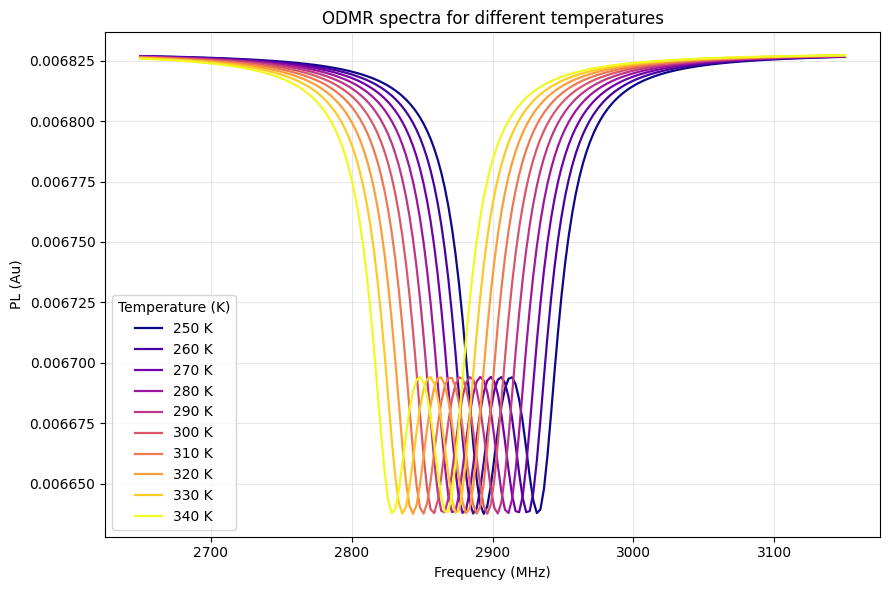

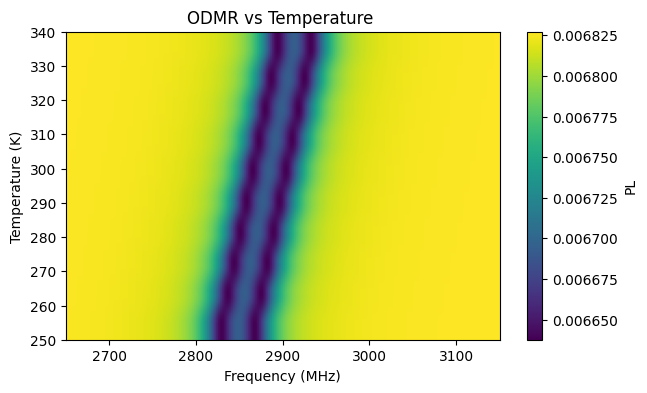

In [ ]:
temps = np.linspace(250, 340, 10)  # temperatures in K (will produce overlayed curves)
RF_sweep = np.linspace(2650, 3150, 200)  # increase RF resolution slightly for smoother curves
PL_vs_T = np.zeros((len(temps), len(RF_sweep)))

# Parameters - these use values from Cell 1 if set, otherwise use defaults from odmrsimulator.py
BNV = odmrsimulator.B  # Gauss (magnetic field) - default: 0.0
rabi_rate = 1.5  # MHz (Rabi frequency)

# Optional: Override parameters here if you want different values for this simulation only
# BNV = 300.0  # Uncomment to override magnetic field for this cell
# odmrsimulator.E_rad_s = 2 * np.pi * 10.0e6 * 2  # Uncomment to override strain (example: 20 MHz)
# odmrsimulator.strain_angle = np.pi / 4  # Uncomment to override strain angle

for ti, T in enumerate(temps):
  for i, RF_freq in enumerate(RF_sweep):
    PL_vs_T[ti, i] = odmrsimulator.NV_ODMR(BNV, RF_freq, rabi_rate, T)

# Overlay plot: one curve per temperature
plt.figure(figsize=(9,6))
cmap = plt.get_cmap('plasma')
colors = [cmap(i/(len(temps)-1)) for i in range(len(temps))]
for ti, T in enumerate(temps):
  plt.plot(RF_sweep, PL_vs_T[ti], label=f"{T:.0f} K", color=colors[ti], linewidth=1.6)

plt.xlabel('Frequency (MHz)')
plt.ylabel('PL (Au)')
plt.title('ODMR spectra for different temperatures')
plt.legend(title='Temperature (K)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Heatmap of simulated spectra 
plt.figure(figsize=(7,4))
plt.imshow(PL_vs_T, aspect='auto', extent=[RF_sweep[0], RF_sweep[-1], temps[0], temps[-1]])
plt.xlabel('Frequency (MHz)')
plt.ylabel('Temperature (K)')
plt.title('ODMR vs Temperature ')
plt.colorbar(label='PL')
plt.show()
